<a href="https://colab.research.google.com/github/keirabasma/Formation-IA/blob/main/CHERADI_Yasmine_regression_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Higher National School of Advanced Technologies (ENSTA)



NAME : **CHERADI Yasmine**

FIELD : **Process Engineering**

SPECIALITY : **Water Treatment**

## **AI Techniques and Tools Subject : Regression Homework**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("homework.csv")
df.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000,6360,2,1,1,yes,no,no,no,no,0,no


In [20]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)
#this code allows the creation of a google sheet file for the dataset

https://docs.google.com/spreadsheets/d/1WvFZhYM9-vXiUpAS-qX_uoTddaz_FFrtaHsH1aF-7QI/edit#gid=0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  546 non-null    int64 
 1   price     546 non-null    int64 
 2   lotsize   546 non-null    int64 
 3   bedrooms  546 non-null    int64 
 4   bathrms   546 non-null    int64 
 5   stories   546 non-null    int64 
 6   driveway  546 non-null    object
 7   recroom   546 non-null    object
 8   fullbase  546 non-null    object
 9   gashw     546 non-null    object
 10  airco     546 non-null    object
 11  garagepl  546 non-null    int64 
 12  prefarea  546 non-null    object
dtypes: int64(7), object(6)
memory usage: 55.6+ KB


In [4]:
df.describe()

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,273.500000,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.692308
std,157.760895,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.861307
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
binary_columns = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']

for col in binary_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,1,0,1,0,0,1,0
1,2,38500,4000,2,1,1,1,0,0,0,0,0,0
2,3,49500,3060,3,1,1,1,0,0,0,0,0,0
3,4,60500,6650,3,1,2,1,1,0,0,0,0,0
4,5,61000,6360,2,1,1,1,0,0,0,0,0,0


**QUESTION 1 :** the simple linear regression (x=lotsize, Y=price)

In [6]:
X = df[['lotsize']]   # Independent variable
y = df['price']       # Dependent variable

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

LinearRegression()

In [9]:
print("Intercept:", simple_model.intercept_)
print("Coefficient:", simple_model.coef_[0])

Intercept: 33003.36216890106
Coefficient: 6.885408879999409


In [10]:
y_pred = simple_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 543921224.559349
R² Score: 0.18583856088525563


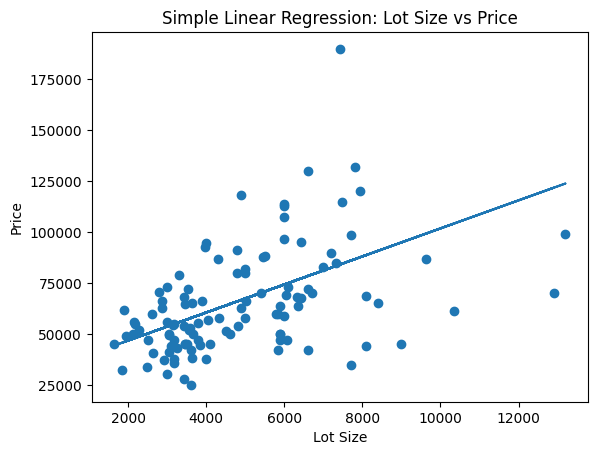

In [11]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Lot Size")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Lot Size vs Price")
plt.show()

**INTERPRETATION OF THE SIMPLE LINEAR REGRESSION :**

The simple linear regression between lot size (independent variable) and price (dependent variable) shows a positive linear relationship, indicating that, on average, property prices tend to increase as lot size increases. The upward-sloping regression line suggests that larger lots are generally associated with higher prices, confirming the expected economic relationship between land size and value. However, the dispersion of points around the regression line indicates a moderate level of variability, meaning that lot size alone does not fully explain price differences. Several observations lie noticeably above or below the line, suggesting the presence of other influential factors. Additionally, a few potential outliers at larger lot sizes may affect the model’s accuracy. Overall, while the regression captures a clear positive trend, its predictive power is limited, and a multiple regression model including additional variables would likely provide a more accurate explanation of property prices.

**PART 2 :** multiple linear regression

In [12]:
X_multi = df[['lotsize', 'bedrooms', 'bathrms', 'stories',
              'driveway', 'recroom', 'fullbase',
              'gashw', 'airco', 'garagepl', 'prefarea']]

y = df['price']
#we have to define multiple features

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

In [14]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

LinearRegression()

In [15]:
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
})

coefficients

,Feature,Coefficient
0,lotsize,3.653990
1,bedrooms,955.865044
2,bathrms,13582.240421
3,stories,7204.649076
4,driveway,6940.012357
5,recroom,4556.744351
6,fullbase,6377.023266
7,gashw,15128.960472
8,airco,12674.616347
9,garagepl,4611.647954


In [17]:
print("Simple Linear Regression R²:", r2_score(y_test, y_pred))
print("Multiple Linear Regression R²:", r2_score(y_test, y_pred_multi))

Simple Linear Regression R²: 0.18583856088525563
Multiple Linear Regression R²: 0.6160238969106218


In [16]:
y_pred_multi = multi_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("R² Score:", r2_score(y_test, y_pred_multi))

MSE: 256524986.5198622
R² Score: 0.6160238969106218


In [21]:
y_pred_multi = multi_model.predict(X_multi)

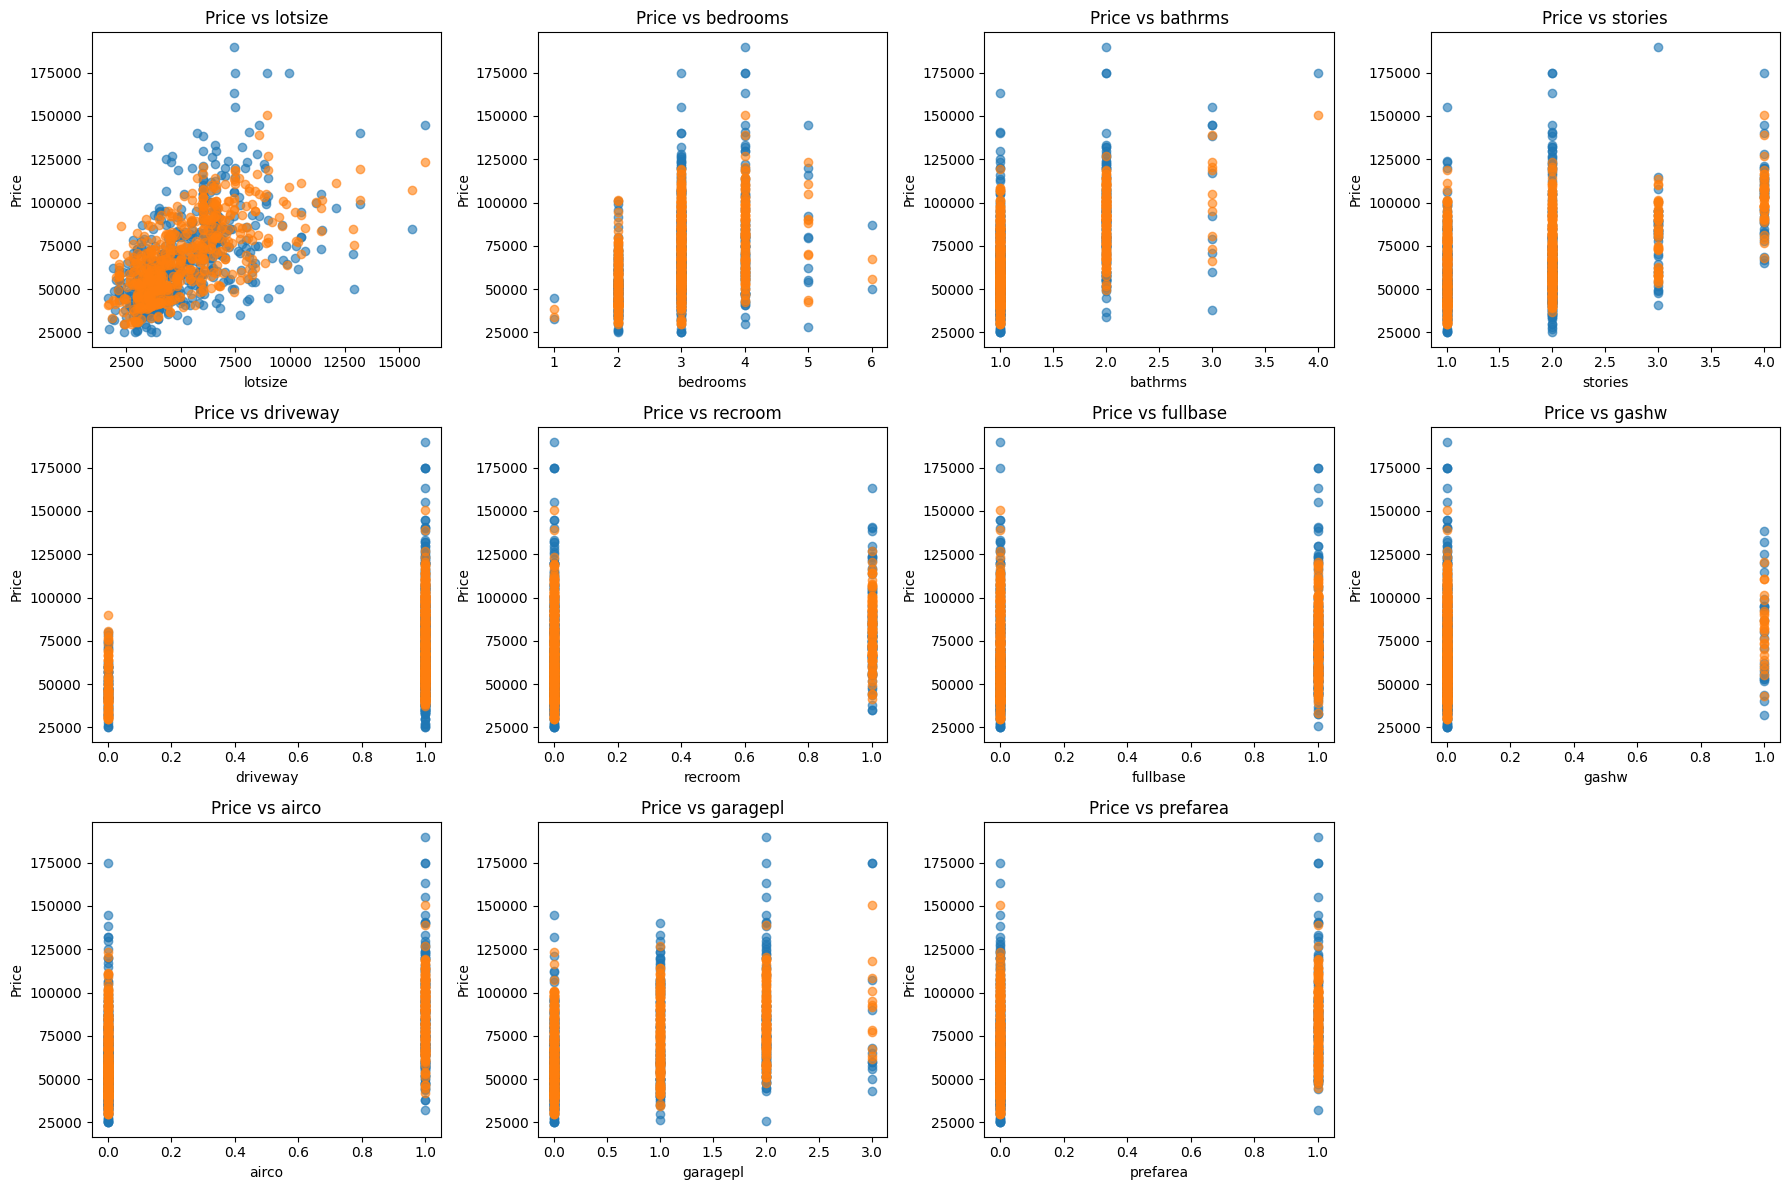

In [22]:
features = X_multi.columns

plt.figure(figsize=(18, 12))

for i, feature in enumerate(features):
    plt.subplot(3, 4, i + 1)

    plt.scatter(df[feature], y, alpha=0.6)
    plt.scatter(df[feature], y_pred_multi, alpha=0.6)

    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"Price vs {feature}")

plt.tight_layout()
plt.show()
# this code create plots for each feature in the same figure

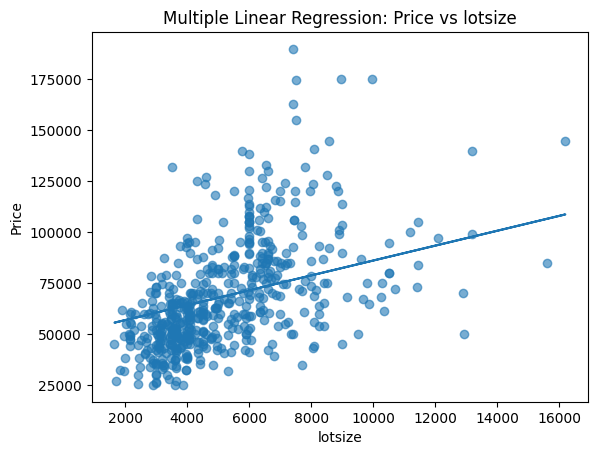

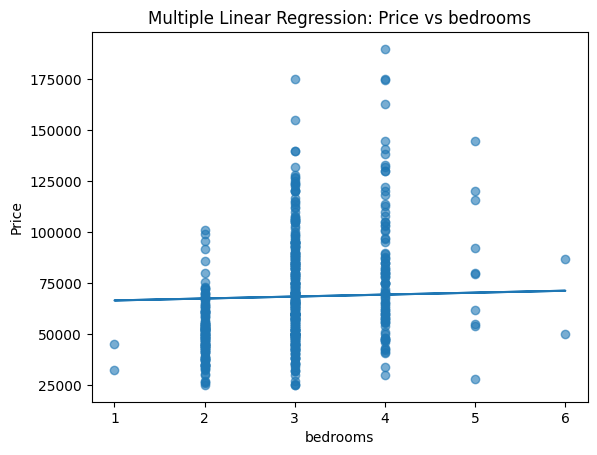

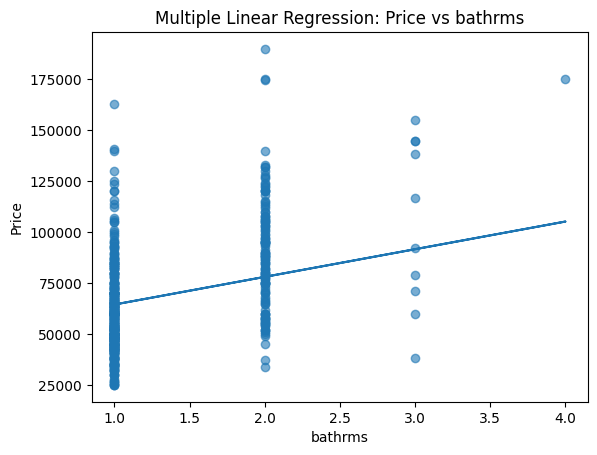

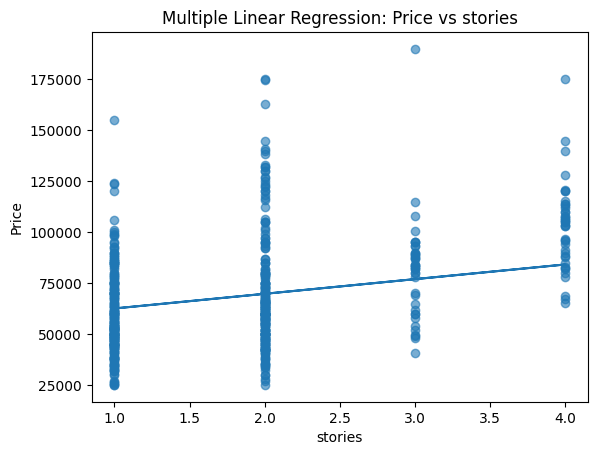

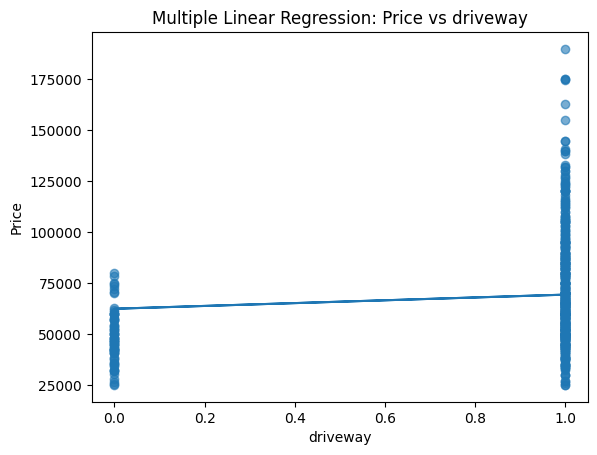

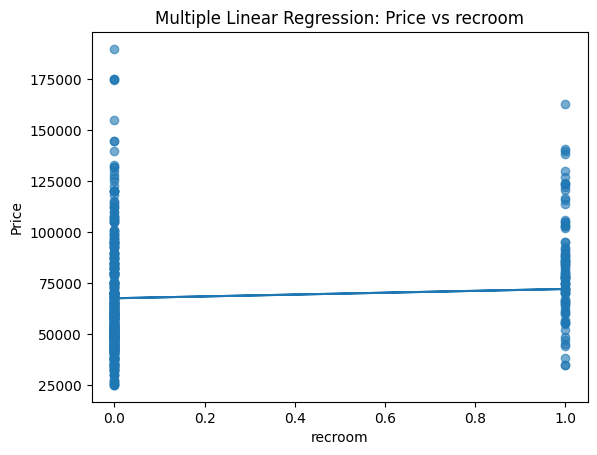

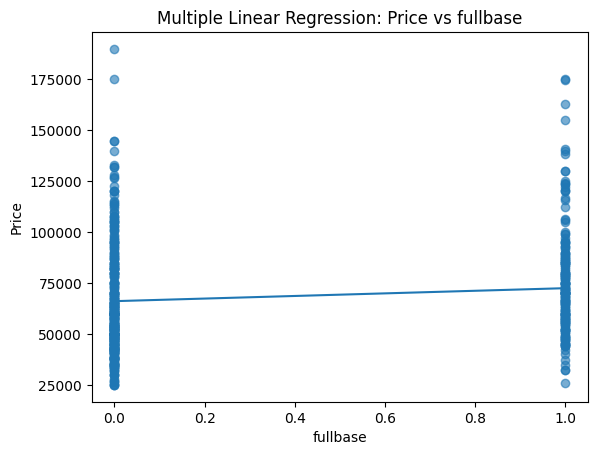

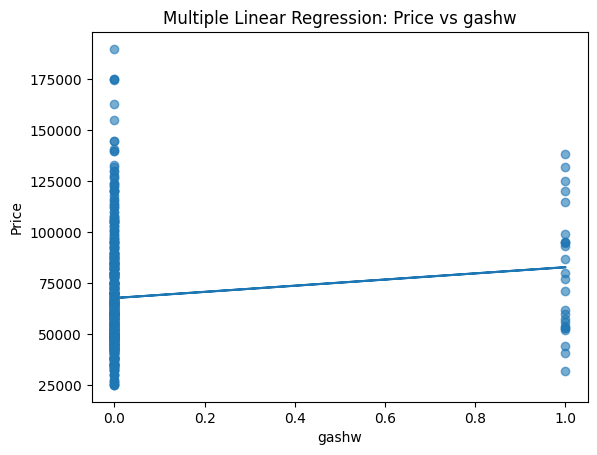

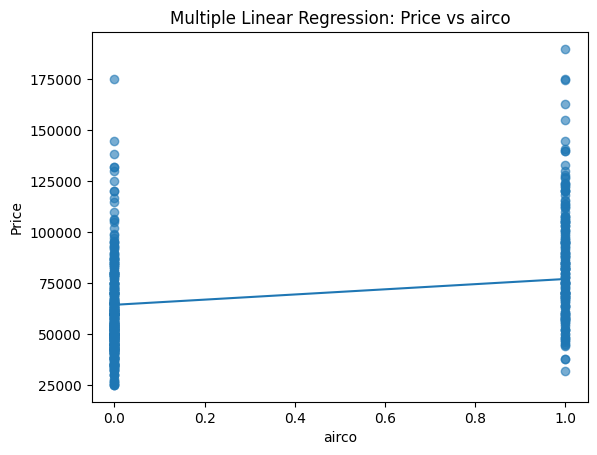

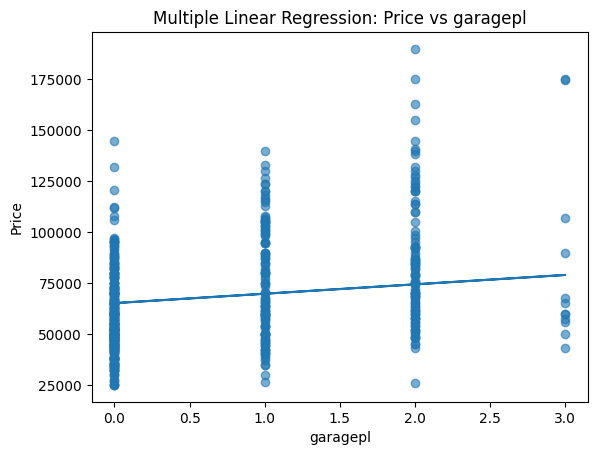

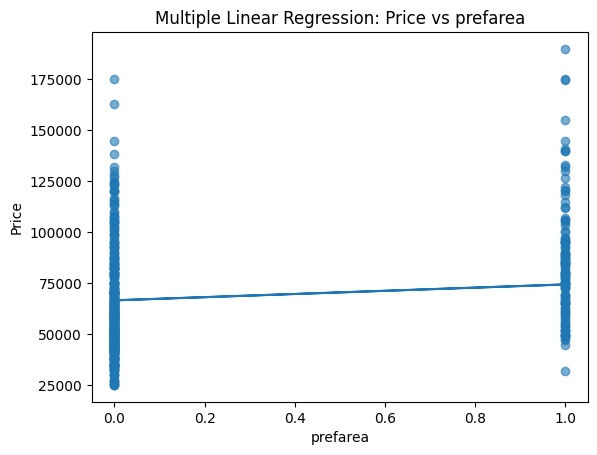

In [23]:
for feature in features:
    X_temp = X_multi.copy()

    # Set all features to their mean
    for col in features:
        X_temp[col] = X_multi[col].mean()

    # Vary only one feature
    X_temp[feature] = X_multi[feature]

    y_temp_pred = multi_model.predict(X_temp)

    plt.figure()
    plt.scatter(X_multi[feature], y, alpha=0.6)
    plt.plot(X_multi[feature], y_temp_pred)

    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"Multiple Linear Regression: Price vs {feature}")
    plt.show()
    # this code create a regression line for each feature (it shows one regression line per feature), keeping other variables at their mean value.

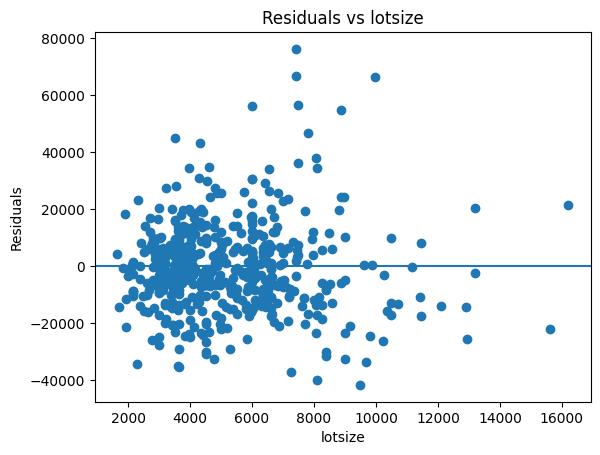

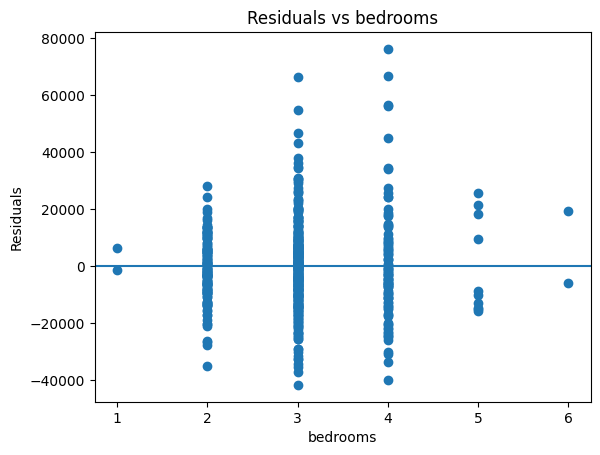

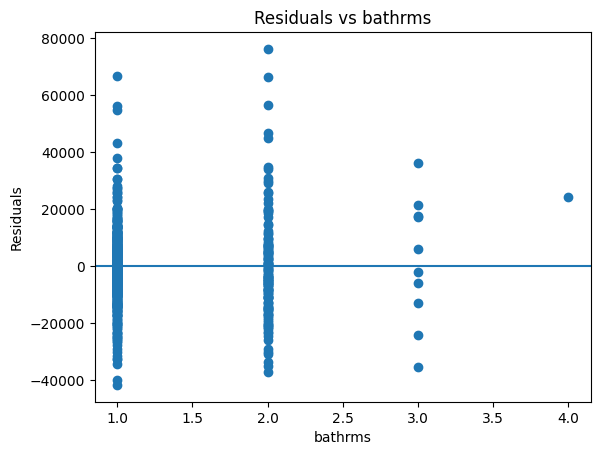

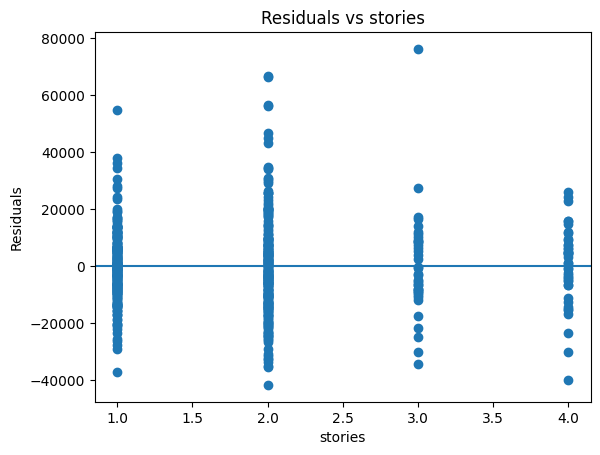

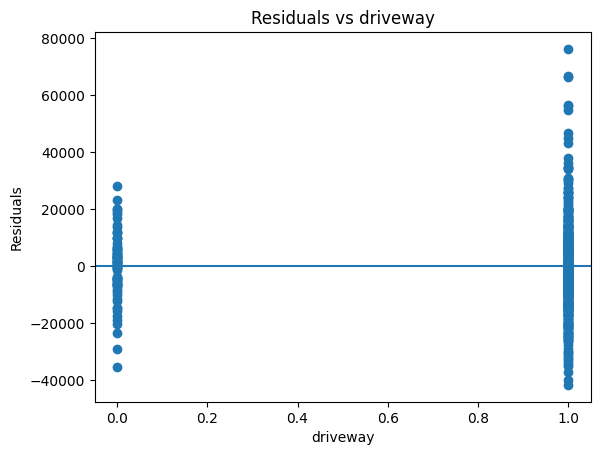

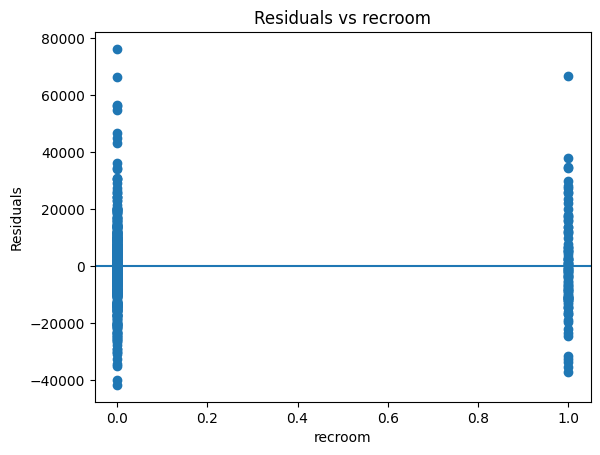

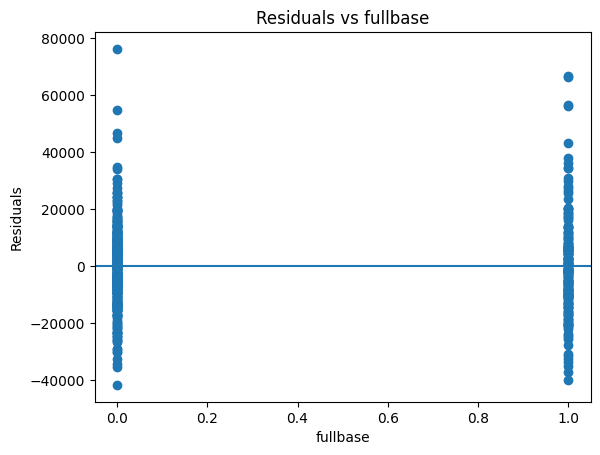

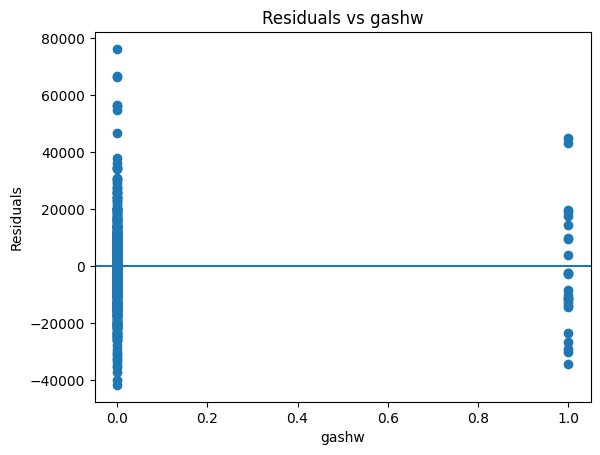

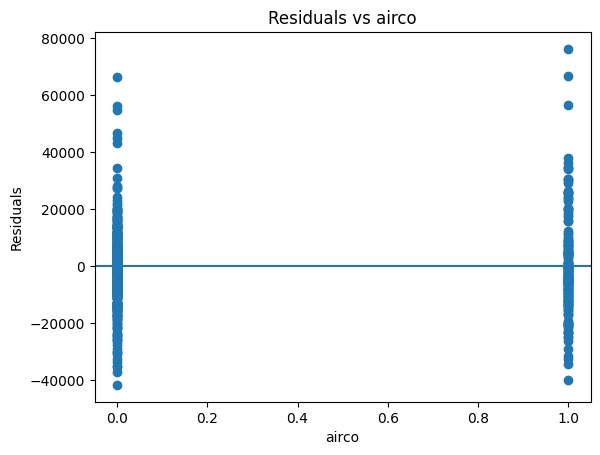

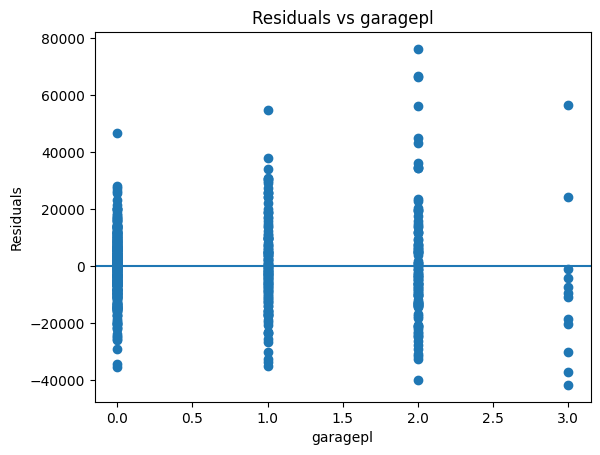

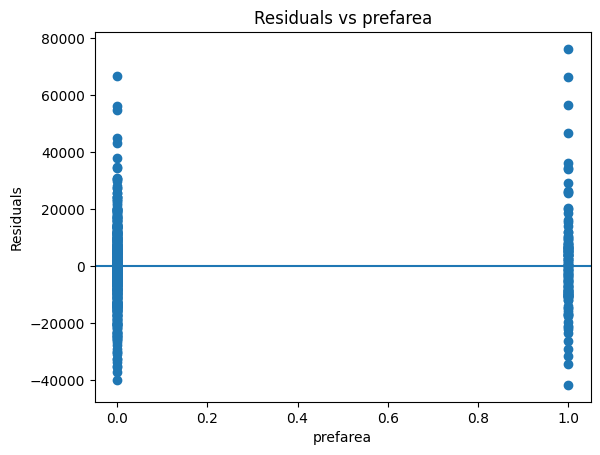

In [24]:
residuals = y - y_pred_multi

for feature in features:
    plt.figure()
    plt.scatter(df[feature], residuals)
    plt.axhline(0)

    plt.xlabel(feature)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs {feature}")
    plt.show()
    #this plots helps to show the quality of our model

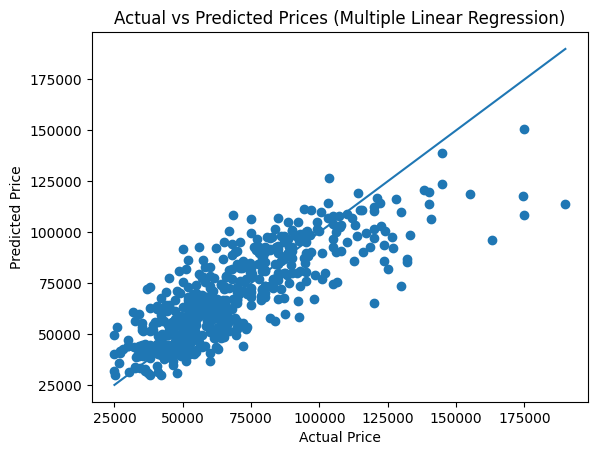

In [26]:
plt.figure()
plt.scatter(y, y_pred_multi)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Multiple Linear Regression)")
plt.show()
# this code allows to evaluate the global performance of our regression model (actual vs predicted prices)

**INTERPRETATION OF THE MULTIPLE LINEAR REGRESSION :**

The multiple linear regression model shows that house prices are influenced by a combination of structural, comfort, and location-related features. The relatively high R² value indicates that the model explains a large proportion of the variability in prices, confirming that using multiple variables provides better predictions than a simple linear model. Features such as lot size, number of bathrooms, stories, garage places, air conditioning, driveway, and preferred area have a positive effect on price, meaning that larger, better-equipped, and well-located houses tend to be more expensive. The residuals are generally centered around zero without strong systematic patterns, suggesting that the linear model is appropriate for this dataset. Overall, the results demonstrate that multiple linear regression is an effective and interpretable approach for modeling this dataset.







**A comparison between simple and multiple linear regressions :**

In this housing dataset, simple linear regression is useful for understanding individual trends (e.g., price increases with lotsize). However, housing prices are influenced by multiple interrelated factors, including size, number of rooms, and amenities such as air conditioning, garage, and preferred area. Therefore, multiple linear regression is more appropriate, as it provides a more accurate and effective estimation of how each feature contributes to house price when all other factors are taken into account.